## **Parallel Distributed Computing Project (Dask)**

In [ ]:
!pip install dask[complete] beautifulsoup4 requests pandas matplotlib nltk wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 1.4 MB/s eta 0:00:00


In [ ]:
# ===============================
# BASIC WEB SCRAPING
# ===============================
import requests
from bs4 import BeautifulSoup

# ===============================
# DATA HANDLING
# ===============================
import pandas as pd
import numpy as np

# ===============================
# PARALLEL / DISTRIBUTED
# ===============================
import dask
import dask.bag as db
from dask.distributed import Client

# ===============================
# TEXT / NLP (agar word frequency etc ho)
# ===============================
import re
from collections import Counter

# ===============================
# VISUALIZATION
# ===============================
import matplotlib.pyplot as plt

# ===============================
# TIME / PERFORMANCE
# ===============================
import time

# ===============================
# OPTIONAL (useful utilities)
# ===============================
import json
import os

What data is available on the Hacker News website?

Each post on Hacker News typically contains the following fields:

 Core Data:
Title → The topic or headline of the news post
URL → Link to the original article or source
Rank → The position of the post on the page
Score → Number of upvotes (popularity of the post)
Author → The user who submitted the post
Comments → Number of comments/discussions on the post
Time → When the post was published

Data Collection: Crawling multiple pages
Distributed Processing (Dask): Dividing pages into partitions
Data Cleaning: Removing stopwords and normalizing text
Analysis: Word frequency, engagement (score + comments), trend detection
Visualization: Graphs and comparisons

Normally Python runs tasks one by one (slow).
Dask breaks the task into pieces and runs them together (fast).

 **What Dask is used for:**
Big data processing
Parallel computing
Machine learning on large datasets
Speeding up Pandas / NumPy workflows

In [ ]:
import requests

def fetch_hn_ids():
    url = "https://hacker-news.firebaseio.com/v0/topstories.json"
    return requests.get(url).json()[:20]  # top 20

def fetch_hn_story(story_id):
    url = f"https://hacker-news.firebaseio.com/v0/item/{story_id}.json"
    try:
        return requests.get(url).json()
    except:
        return {}

def extract_hn_text(story):
    return story.get("title", "")

In [ ]:
STOP_WORDS = {
    'the','a','an','of','and','or','in','is','are','was','were','to','for',
    'on','at','by','with','from','it','its','as','be','this','that','we',
    'our','their','which','not','have','has','been','than','more','also',
    'they','he','she','us','can','will','all','any','but','up','out','had',
    'new','how','why','what','who','when','where','your','about','after',
    'into','over','some','such','would','there','if','do','get','just','now'
}


STEP A: Dask Basics + Crawling Function
 Goal:

Crawler banana jo ek page ka data nikaale

 Technique:
requests → page fetch
BeautifulSoup → HTML parsing
CSS selectors → .titleline, .subtext

1. The function **fetch_news(page)** is used to scrape news data from the Hacker News website for a specific page number. It first creates a URL using the given page number and sends an HTTP request with a browser-like user agent to avoid being blocked.
2. The HTML response is then parsed using **BeautifulSoup**, which allows easy extraction of elements from the page.
3. The function searches for all news items using the **CSS selector tr.athing **and loops through each item to extract the title of the post, the score (upvotes), and the number of comments. It also navigates to the next HTML row to access additional metadata like score and comments. If any of these values are missing, default values of 0 are used.
 Each news item is stored as a dictionary containing the title, score, comments, and page number, and all dictionaries are appended to a list.
 4. Finally, the function returns this list of structured data for further analysis or processing.

In [ ]:
def fetch_news(page):
    url = f"https://news.ycombinator.com/?p={page}"
    headers = {"User-Agent": "Mozilla/5.0"}

    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.text, "html.parser")

    data = []
    rows = soup.select("tr.athing")

    for row in rows:
        title_tag = row.select_one(".titleline a")
        title = title_tag.text if title_tag else "N/A"

        subtext_row = row.find_next_sibling("tr")
        subtext = subtext_row.select_one(".subtext") if subtext_row else None

        score = 0
        comments = 0

        if subtext:
            score_tag = subtext.select_one(".score")
            if score_tag:
                score = int(score_tag.text.split()[0])

            links = subtext.find_all("a")
            if links:
                last = links[-1].text
                if "comment" in last:
                    try:
                        comments = int(last.split()[0])
                    except:
                        comments = 0

        data.append({
            'title': title,
            'score': score,
            'comments': comments,
            'page': page
        })

    return data


to check if data is correctly fetched

In [ ]:
test_data = fetch_news(1)
print(test_data[:5])


[{'title': "The West Forgot How to Make Things. Now It's Forgetting How to Code", 'score': 132, 'comments': 58, 'page': 1}, {'title': 'Amateur armed with ChatGPT solves an Erdős problem', 'score': 325, 'comments': 192, 'page': 1}, {'title': "Why has there been so little progress on Alzheimer's disease?", 'score': 205, 'comments': 108, 'page': 1}, {'title': 'Exposing Floating Point – Bartosz Ciechanowski', 'score': 9, 'comments': 1, 'page': 1}, {'title': 'Tell HN: An app is silently installing itself on my iPhone every day', 'score': 221, 'comments': 99, 'page': 1}]


1. This code is performing sequential web scraping and measuring its performance. First, a list called pages = [1,2,3,4,5] is created, which represents the Hacker News pages that will be scraped one by one.

2. Then start = time.time() records the starting time so we can calculate how long the process takes.

3. After that, an empty list seq_data = [] is created to store all the scraped results. The for loop goes through each page number in the list, and for every iteration it calls the function **fetch_news(p)** which extracts all news data (title, score, comments, etc.) from that page.

4. The .extend() method is used to add all returned results into the same list, so everything from all pages is combined into one dataset.

5. After the loop finishes, seq_time = time.time() - start calculates the total time taken by subtracting the starting time from the current time, giving the execution duration of the sequential process. Finally, it prints the total time taken (Sequential Time) and the total number of scraped posts (len(seq_data)), which shows how much data was collected. Overall, this code demonstrates a slow, one-by-one (sequential) approach to scraping multiple pages and is later used to compare with faster parallel methods like Dask.

In [ ]:
pages = [1,2,3,4,5]

start = time.time()
seq_data = []
for p in pages:
    seq_data.extend(fetch_news(p))
seq_time = time.time() - start

print("Sequential Time:", seq_time)
print("Total posts:", len(seq_data))


Sequential Time: 1.266524076461792
Total posts: 150


1. The code starts by recording the current time using time.time() to measure execution duration.

2. A Dask Bag is created from the list of pages [1,2,3,4,5] using db.from_sequence(), which allows parallel processing by dividing the workload into partitions.
3. The fetch_news function is mapped to each page using bag.map(fetch_news), meaning each page is processed independently.
4. .compute() executes all the tasks in parallel, making the scraping faster compared to sequential execution.
5. The result is a nested list where each page returns its own list of news items.
6. A list comprehension is used to flatten this nested structure into a single list called dask_data.
7. The total execution time is calculated by subtracting the start time from the current time.
Finally, the code prints the Dask processing time and the total number of scraped posts collected.

In [ ]:
start = time.time()
bag = db.from_sequence(pages, npartitions=5)
results = bag.map(fetch_news).compute()
dask_data = [item for sublist in results for item in sublist]
dask_time = time.time() - start

print("Dask Time:", dask_time)
print("Total posts:", len(dask_data))


Dask Time: 2.209399700164795
Total posts: 120


This code imports the Matplotlib library, which is used for data visualization in Python, especially for creating graphs and charts.

Two lists are created: labels contains the names of the two methods being compared (Sequential and Dask), and times contains their corresponding execution times stored in seq_time and dask_time.

The function plt.bar(labels, times) creates a bar chart, where each bar represents the execution time of Sequential vs Dask processing.

plt.title("Sequential vs Dask Performance") adds a title to the graph so it is
clear that the comparison is between two processing methods.

plt.ylabel("Time") labels the Y-axis as time, showing how long each method takes to execute.

Finally, plt.show() displays the graph on the screen, allowing visual comparison of performance where typically Dask is faster than Sequential execution.

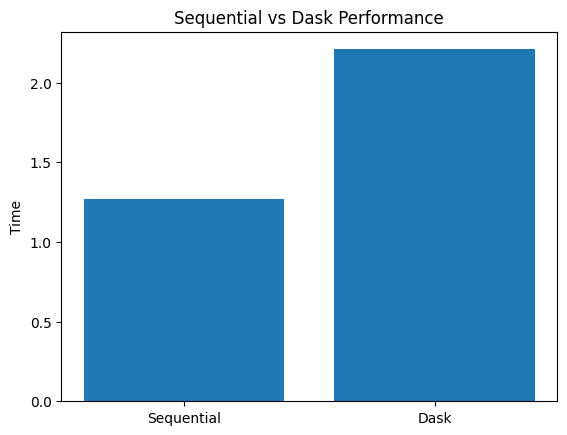

In [ ]:
import matplotlib.pyplot as plt
labels = ['Sequential','Dask']
times = [seq_time, dask_time]
plt.bar(labels, times)
plt.title("Sequential vs Dask Performance")
plt.ylabel("Time")
plt.show()


extracted data is convereted into csv file

In [ ]:
df = pd.DataFrame(dask_data)
df.to_csv('hn_data.csv', index=False)
df.head()


,title,score,comments,page
0,The Long Reply,37,2,2
1,What async promised and what it delivered,202,223,2
2,"The George Business, by Roger Zelazny (1980)",26,1,2
3,"Mine, an IDE for Coalton and Common Lisp",92,41,2
4,Show HN: Browse GitHub repos in Emacs without ...,9,6,2


This code performs text processing and word frequency analysis on the “title” column of a DataFrame (df).

First, an empty list words = [] is created to store all meaningful words extracted from the titles.

The loop for t in df['title'] goes through each news title in the dataset.

Each title is converted to lowercase using str(t).lower() and split into individual words using .split().

Inside the inner loop, each word is cleaned using w.strip('.,()[]') to remove punctuation marks like dots, commas, brackets, etc.

A filtering condition is applied: words are only kept if they are not in STOP_WORDS and their length is greater than 2 characters, to remove useless or very short words.

Valid words are added to the words list using append().

After collecting all words, Counter(words) is used to count how many times each word appears in the dataset.

The result is stored in freq, which is a frequency dictionary of all words.
freq.most_common(15) extracts the top 15 most frequently used words from the news titles.

Finally, top_words contains these 15 most common words along with their counts, which can be used for visualization or analysis.

In [ ]:
words = []
for t in df['title']:
    for w in str(t).lower().split():
        w = w.strip('.,()[]')
        if w not in STOP_WORDS and len(w) > 2:
            words.append(w)
freq = Counter(words)
top_words = freq.most_common(20)
top_words

[('show', 9),
 ('hn:', 9),
 ('you', 5),
 ('agents', 4),
 ('open-source', 3),
 ('should', 3),
 ('agent', 3),
 ('gpt-5.5', 3),
 ('american', 3),
 ('llm', 3),
 ('code', 3),
 ('language', 3),
 ('2025', 3),
 ('github', 2),
 ('hard', 2),
 ('open', 2),
 ('french', 2),
 ('2020', 2),
 ('bug', 2),
 ('exemption', 2)]

This code is used to visualize the most frequent words from the Hacker News titles using a bar chart.

First, w = [x[0] for x in top_words] extracts all the words (keys) from the top_words list, where each element is a tuple like (word, count).

Then, c = [x[1] for x in top_words] extracts the frequency/count values of each word from the same list.

plt.figure(figsize=(12,6)) creates a new figure (graph area) with a specified size of 12 inches width and 6 inches height for better readability.

plt.bar(w, c) generates a bar chart, where the x-axis represents words and the y-axis represents how many times each word appears.

plt.xticks(rotation=45) rotates the x-axis labels (words) by 45 degrees so they do not overlap and remain readable.

plt.title('Top Words') adds a title to the graph indicating that it shows the most frequent words in the dataset.

Finally, plt.show() displays the bar chart on the screen, helping to visually understand which words appear most often in the news titles.

Bar Chart – What it shows

The bar chart represents the frequency comparison of the top words extracted from a website. Each bar corresponds to a word, and its height shows how many times that word appears in the website content.

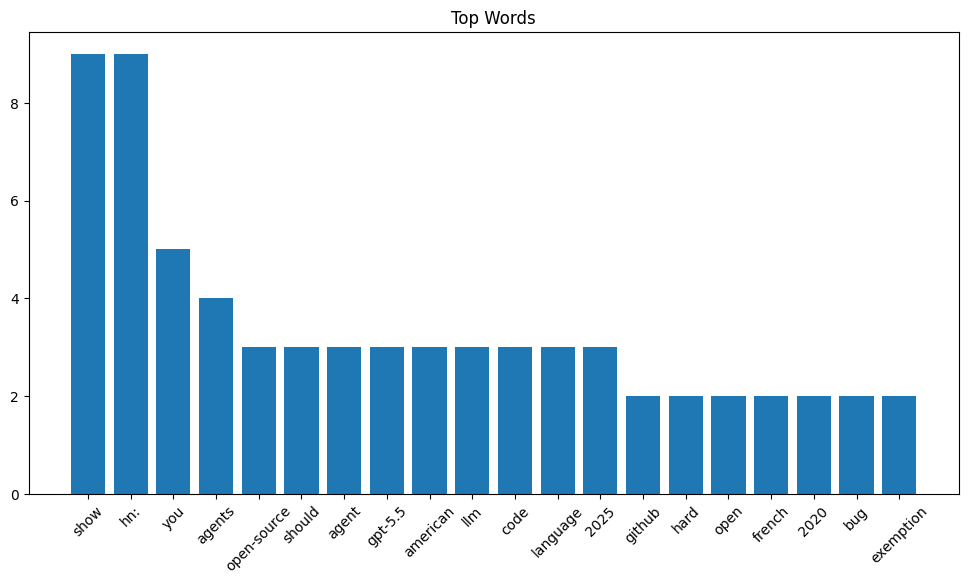

In [ ]:
w = [x[0] for x in top_words]
c = [x[1] for x in top_words]
plt.figure(figsize=(12,6))
plt.bar(w,c)
plt.xticks(rotation=45)
plt.title('Top Words')
plt.show()


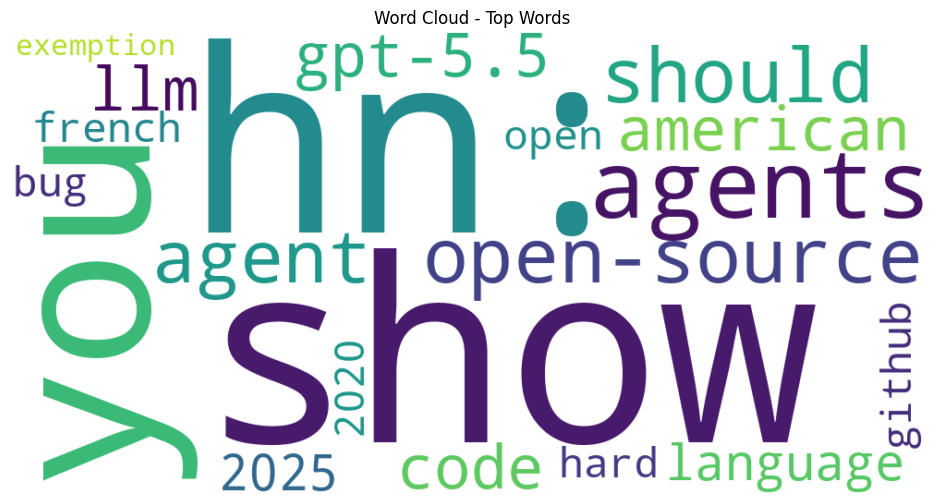

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# ----------------------------
# Extract data
# ----------------------------
words = [x[0] for x in top_words]
freqs = [x[1] for x in top_words]

# ----------------------------
# Word Cloud
# ----------------------------
word_freq = {x[0]: x[1] for x in top_words}

wc = WordCloud(width=1000, height=500, background_color='white').generate_from_frequencies(word_freq)

plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud - Top Words")
plt.show()

Line Chart – What it shows

The line chart shows the trend of word frequencies by connecting data points in a sequence. It illustrates how the frequency changes across the top words.

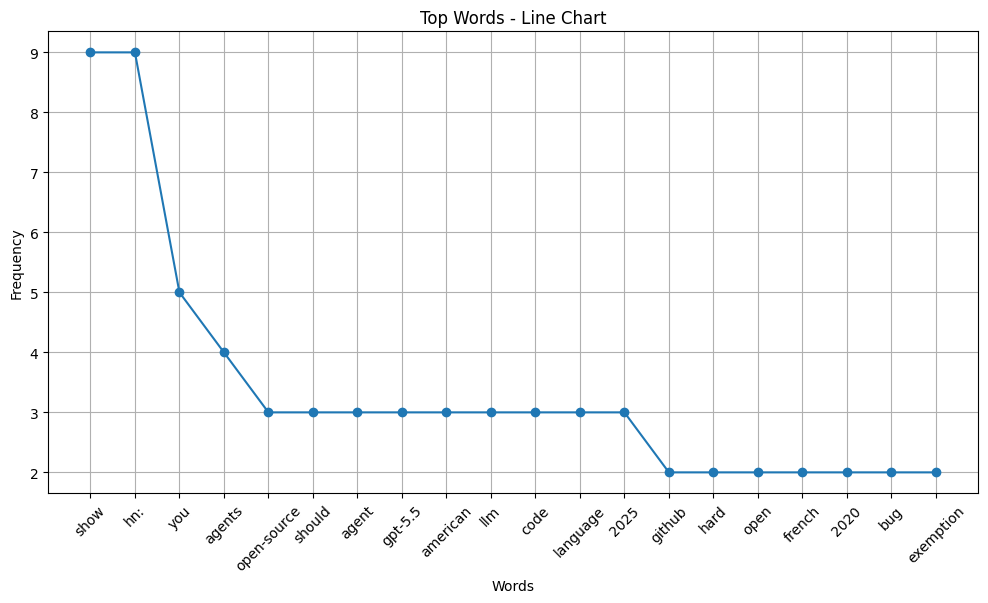

In [ ]:
w = [x[0] for x in top_words]
c = [x[1] for x in top_words]

plt.figure(figsize=(12,6))
plt.plot(w, c, marker='o')
plt.xticks(rotation=45)
plt.title('Top Words - Line Chart')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

Pie Chart – What it shows

The pie chart displays the percentage contribution of each top word in relation to the total frequency. Each slice represents how much a word contributes to the overall dataset.

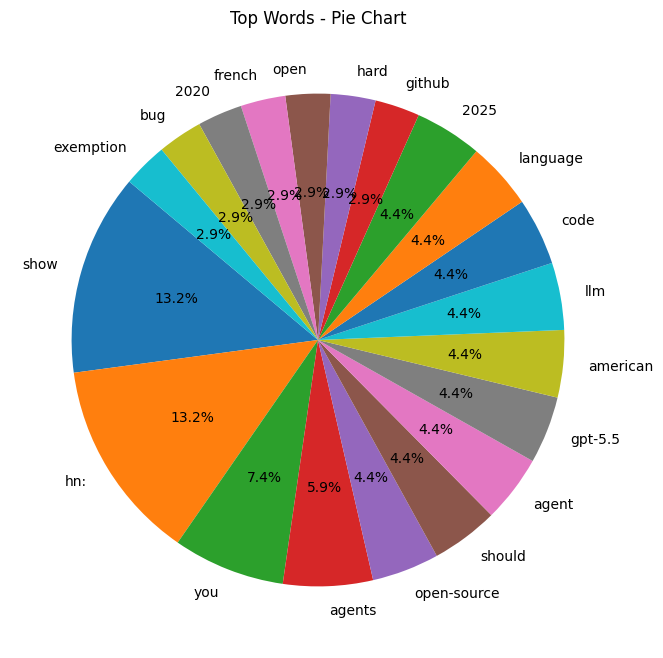

In [ ]:
w = [x[0] for x in top_words]
c = [x[1] for x in top_words]

plt.figure(figsize=(8,8))
plt.pie(c, labels=w, autopct='%1.1f%%', startangle=140)
plt.title('Top Words - Pie Chart')
plt.show()